In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

import scipy
import datetime as dt
import numpy as np
import pandas as pd

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans

In [2]:
def plot_audio_seg_spectrogram(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
            labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

In [3]:
HARD_DRIVE_LOC = Path('/Volumes/Elements')

In [4]:
experiment_folder = HARD_DRIVE_LOC / 'UBNA_array_tests2026' / '20260520_test' / '6_audiomoth_GPS'
experiment_folder

PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS')

In [5]:
all_wav_files = list(experiment_folder.glob('STF_*/*.WAV'))
all_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_027/20260520_204927.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_029/20260520_204029.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_029/20260520_204640.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_025/20260520_203942.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_025/20260520_204641.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_026/20260520_204209.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_026/20260520_204640.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_023/20260520_205039.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_028/20260520_205239

In [59]:
valid_wav_files = []
for wav_file in all_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S.WAV')
    if wave_file_dt >= dt.datetime(2026, 5, 20, 20, 43, 0):
        valid_wav_files += [wav_file]
valid_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_027/20260520_204927.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_029/20260520_204640.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_025/20260520_204641.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_026/20260520_204640.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_023/20260520_205039.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/20260520_test/6_audiomoth_GPS/STF_028/20260520_205239.WAV')]

In [35]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_023': '002', 'STF_026': '008', 'STF_025': '009', 'STF_029': '010', 'STF_028': '012', 'STF_027': '014'}
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_023': '002',
 'STF_026': '008',
 'STF_025': '009',
 'STF_029': '010',
 'STF_028': '012',
 'STF_027': '014'}

In [75]:
recording_start_dt = dt.datetime(2026, 5, 20, 21, 5, 41, 800000)
recording_start_dt

datetime.datetime(2026, 5, 20, 21, 5, 41, 800000)

In [76]:
SAMPLERATE = 192000

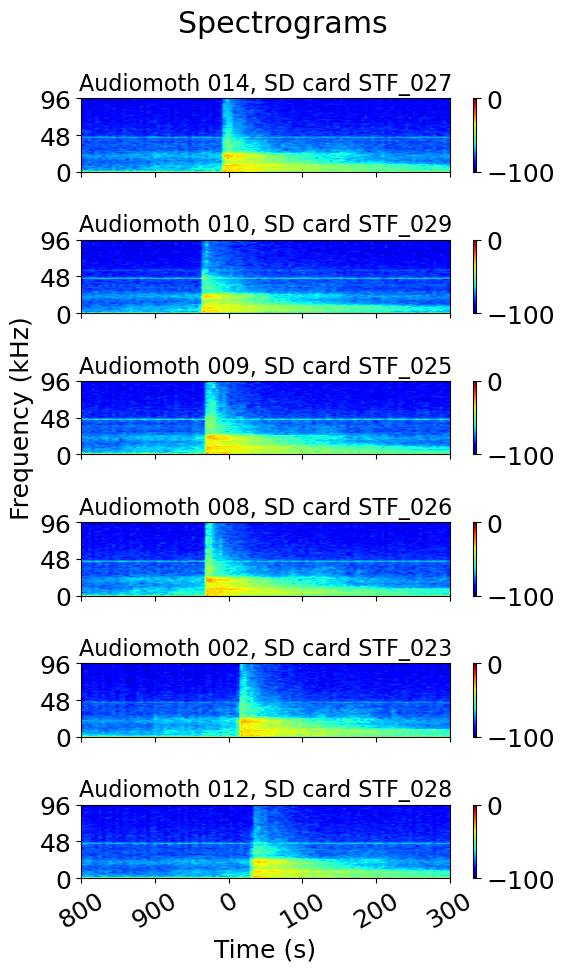

In [77]:
fig, ax_all = plt.subplots(6, 1, figsize=(6, 10), sharex = True)
plt.rcParams.update({'font.size': 18})
fig.suptitle(f'Spectrograms')

for i, example_wav_file in enumerate(valid_wav_files):
    ax = ax_all[i]
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]

    example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
    samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
    recorded_audio = sf.SoundFile(example_wav_file)
    read_offset = samples_until_recording_start
    read_duration_in_secs = 0.5
    recorded_audio.seek(int(SAMPLERATE*read_offset))
    audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))

    vmax = 0
    vmin = -100

    audio_features = dict()
    audio_features['audio_seg'] = audio_seg
    audio_features['sample_rate'] = SAMPLERATE
    audio_features['start'] = read_offset
    audio_features['duration'] = read_duration_in_secs

    spec_features = dict()
    spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = vmin
    spec_features['vmax'] = vmax

    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card}", fontsize=16)
    spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    ax.set_yticks(ticks=np.linspace(0, 1, 3), labels=np.linspace(0, fs/2000, 3).astype('int'))
    times = []
    for s in np.linspace(0, duration, 6):
        times += [str(int(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%f")[:3]))]
    ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 6), labels=times, rotation=30)
    fig.colorbar(im, ax=ax)
ax_all[2].set_ylabel("Frequency (kHz)")
ax_all[5].set_xlabel("Time (s)") 
fig.tight_layout()
plt.show()